In [51]:
import pandas as pd
import numpy as np
import scipy as sp
from scipy.io import mmread
from scipy.sparse import csr_matrix, bmat
import matplotlib.pyplot as plt

NameError: name 'beta' is not defined

In [5]:
A.data

array([1., 1., 1., ..., 1., 1., 1.])

In [53]:
def statistike(S,A):
    S = S.tocsr()
    A = A.tocsr()
    num_comm = np.diff(A.indptr) # number of cummunities each person is a part of
    more_than_15_comm = np.array([i for i in range(num_comm.shape[0])])[num_comm > 15]
    more_than_30_comm = num_comm[num_comm > 30].shape[0]
    more_than_50_comm = num_comm[num_comm > 50].shape[0]

    num_friends = np.diff(S.indptr) # number of cummunities each person is a part of
    more_than_15_friend = num_friends[num_friends > 15].shape[0]
    more_than_30_friend = num_friends[num_friends > 30].shape[0]
    more_than_50_friend = num_friends[num_friends > 50].shape[0]

    plt.boxplot(num_comm, vert=True, patch_artist=True, boxprops=dict(facecolor="lightblue"))


    return(np.mean(num_comm), more_than_15_comm,more_than_30_comm,more_than_50_comm, np.mean(num_friends), more_than_15_friend,more_than_30_friend,more_than_50_friend)


In [476]:
def create_random_symmetric_neighborhood_matrix(size, sparsity=0.1, seed=None):
    """
    Create a symmetric neighborhood matrix with randomness.
    
    Args:
        size (int): Size of the square matrix.
        sparsity (float): Probability of a connection (between 0 and 1).
        seed (int): Seed for reproducibility (optional).
    
    Returns:
        np.ndarray: A symmetric neighborhood matrix.
    """
    if seed is not None:
        np.random.seed(seed)
    
    # Initialize the matrix
    matrix = np.zeros((size, size), dtype=int)
    
    # Randomly add connections
    for i in range(size):
        for j in range(i, size):  # Ensure symmetry
            if i == j:  # Self-loop
                matrix[i, j] = 0
            else:
                if np.random.rand() < sparsity:
                    matrix[i, j] = 1
                    matrix[j, i] = 1  # Ensure symmetry
    
    return matrix


In [55]:
#recimo da nas zanimaju samo veze za jednu osobu
def get_neighbors_submatrix(S,A, index, depth=1):
    if not sp.sparse.isspmatrix_csr(S):
        S = S.tocsr()
    if not sp.sparse.isspmatrix_csr(A):
        A = A.tocsr()
    
    
    if(type(index) == int): # index moze biti indeks jedne osobe, ili moze biti array ljudi koje zelimo 
        vertices = [index]
    else:
        vertices = index
    
    all_neighbors = set()
    for vertex in vertices:
        neighbors = S[vertex].indices
        gone_thrugh = set()
        vertex_neighbors = set(neighbors).union(set(np.array([vertex])))
        for i in range(depth-1):
            diff = vertex_neighbors - gone_thrugh
            gone_thrugh = vertex_neighbors.copy()
            for neighbor in diff:
                vertex_neighbors.update(S[neighbor].indices)
        all_neighbors.update(vertex_neighbors)
    
    submatrix_indices = sorted(all_neighbors)
    
    submatrix_S = S[submatrix_indices, :][:, submatrix_indices]
    submatrix_A = A[submatrix_indices, :]
    
    return submatrix_S,submatrix_A, submatrix_indices

In [77]:
#funkcija prima matricu, index retka/stupca i treshold, te postotak 
#posavit će određeni postotak vrijednosti u zadanom retku koje su na indexu većem od tresholda na nulu
# ideja da se stavi treshold na broj ljudi u matrici tako da se makne određeni postotak zajednica pa ćemo testirat 
#s obizrom na maknute zajednice 
def remove_random(matrix, treshold = 0, index = -1, fraction=0.3, max_remove = 15):
    coo = matrix.tocoo()
    
    if (type(index) == int and index == -1):   # index moze biti indeks jedne osobe, moze bitit -1 ako svima zelimo maknuti, ili moze biti array ljudi kojima zelimo maknuti
        indexes = [i for i in range(treshold)]
    elif(type(index) == int):
        indexes = [index]
    else:
        indexes = index


    uklonjeni = dict()
    row_indices_to_zero = np.array([])
    col_indices_to_zero = np.array([])
    for i in indexes:
        uklonjeni[i] = None
        row_nonzero_indices = coo.row[(coo.row == i)*((coo.col >= treshold))]  # Non-zero in row
        col_nonzero_indices = coo.col[(coo.row == i)*((coo.col >= treshold))]  # Non-zero in column

        if(row_nonzero_indices.shape[0] == 0):
            continue
        num_to_zero = min(max_remove,max(1, int(len(col_nonzero_indices) * fraction)))  # At least one index
        mask = np.zeros(len(col_nonzero_indices), dtype=bool)
        zero_indices = np.random.choice(len(col_nonzero_indices), num_to_zero, replace=False)
        mask[zero_indices] = True

        row_indices_to_zero = np.concatenate((row_indices_to_zero,np.array(row_nonzero_indices)[mask], np.array(col_nonzero_indices)[mask]))
        col_indices_to_zero = np.concatenate((col_indices_to_zero,np.array(col_nonzero_indices)[mask], np.array(row_nonzero_indices)[mask]))
        uklonjeni[i] = np.array(col_nonzero_indices)[mask]

    # Reconstruct the matrix
    new_matrix = matrix - sp.sparse.coo_matrix((np.ones_like(row_indices_to_zero), (row_indices_to_zero, col_indices_to_zero)), shape=coo.shape, dtype=bool)
    
    return new_matrix, uklonjeni
#vraća novu matricu susjedstva i dictionary gdje je svakom covjeku pridruzen vektor uklonjenih zajednica

In [59]:
def Katz_matrix(C, beta = 0.001):
    #eigenvalues, _ = sp.sparse.linalg.eigsh(C)
    #beta = 1/np.max(eigenvalues)*0.9 
    mat = C.copy()
    fakt = 1
    katz = mat
    for i in range(100):
        if(fakt < 0.0000000001):
            break
        mat = C@mat
        fakt = fakt*beta
        katz +=  fakt*mat
    return katz

In [61]:
def katz_inverse(C,index,beta = 0.001):
    mat =  sp.sparse.eye(C.shape[0], format='csr') - beta*C
    b = np.zeros(C.shape[0])
    b[index] = 1
    return sp.sparse.linalg.spsolve(mat,b)# tu treba probati iterativne metode da bude brže


In [63]:
def latent_factor_matrix(C, dimension = 30):
    U, Sigma, Vt = np.linalg.svd(C)
    return U[:,:dimension]@Sigma@Vt[:dimension,:]

In [89]:
def recommendation(Ct, recommendation_matrix, n, num_recommendations = 15): #prima redak matrice susjedstva i redak recom matrice koji odogovaraju istom indexu
    val = recommendation_matrix[n:] #u val se nalaze vrijednosti recom matrice u dijelu koji se odnosi na zajednice
    sorted_indices = np.argsort(val)[::-1] #tu dobivamo redom indekse na kojima val ima najveće iznose
    out = set()
    print (n+len(sorted_indices)-1)
    print (Ct.shape)
    for i in sorted_indices:
        if(Ct[n+i] == 0): # biramo samo one vrijednosti na kojima Ct ima 0 tj one zajednice s kojima korisnik još nije povezan
            out.add(n+i)
        if(len(out) == num_recommendations):
            break
    return out

In [93]:
def true_positive(Ct,recommendation_matrix, correct , n,  index =-1,  num_recommendations = 15): #prima matricu susjedstva, recommendation matrix, rječnik s točnim skupinama, a index su indexi koje testiranmo
                                                                                                #matrica susjedstva je ona iz koje smo maknuli neke zajednice, a correct sadrži te zajednice koje smo maknuli
    if (type(index) == int and index == -1):  # index moze biti indeks jedne osobe ili moze biti array ljudi koje zelimo testirati                                                   
        indexes = [i for i in range(n)]  
    elif(type(index) == int):
        indexes = [index]
    else:
        indexes = index
    sum = 0
    
    for i in indexes:
        recommendations = recommendation(Ct[i, :].toarray().flatten(), recommendation_matrix[i, :], n, num_recommendations) #šaljemo redak matrice susjedstva i recommendation matrice za osobu za koju nas zanimaju preporuke 
        sum += len(recommendations & set(correct[i]))
    return sum
        

In [99]:
def mean_specificity(Ct,recommendation_matrix, correct , n,  index =-1,  num_recommendations = 15):
    if (type(index) == int and index == -1):  # index moze biti indeks jedne osobe ili moze biti array ljudi koje zelimo testirati                                                   
        indexes = [i for i in range(n)]  
    elif(type(index) == int):
        indexes = [index]
    else:
        indexes = index
    sum = 0
    
    for i in indexes:
        recommendations = recommendation(Ct[i, :].toarray().flatten(), recommendation_matrix[i, :], n, num_recommendations) #šaljemo redak matrice susjedstva i recommendation matrice za osobu za koju nas zanimaju preporuke 
        orig_neg = set()
        for g in range(5000):
            if Ct[i, n+g] == 0 and g not in set(correct[i]):
                orig_neg.add(g)
        
        izost_neg = set()
        for g in range(5000):
            if Ct[i, n+g] == 0 and g not in set(correct[i]) and recommendation_matrix[i, n+g]==0:
                izost_neg.add(g)

        sum += len(izost_neg)/len(orig_neg)
    return sum/len(index)

In [177]:
# sad testiramo metode
# kako sve mozemo testirat:

#uzimanjem podgrafa pa računanjem za sve ljude u podgrafu
    #micanjem samo određenih zajednica za jednu osobu
    #micanjem zajednica za sve osobe odjednom

#odabirom osobe pa uzimanje podgrafa tako da uzimamo njegove susjede pa micanjem njegovih zajednica pa određivanjem preporuka za njega


In [79]:
def load_communities(lokacija,n,k): # za amazon dataset
    rows = []
    cols = []
    data = []
    with open(lokacija, "r") as file:
        num = 0
        
        for line in file:
            row = [int(num) for num in line.strip().split("\t")]
            cols += ([num for i in range(len(row))])
            rows += row
            data += ([1 for i in range(len(row))])
            num += 1
    return sp.sparse.coo_matrix((data,(rows,cols)), shape = (n,k), dtype=bool)


In [97]:
# amazon dataset

# ovo sam izvukao iz podataka
k = 5000

prijateljstva = pd.read_csv("com-amazon.ungraph.txt", sep= '\t') # ucitavanje podatke
a = prijateljstva.iloc[:,0].to_numpy() - 1
b = prijateljstva.iloc[:,1].to_numpy() - 1
rows = np.concatenate((a,b))
cols = np.concatenate((b,a))

n = max(rows)+1
data = np.ones((rows.shape[0]))
S = sp.sparse.coo_matrix((data,(rows,cols)), shape = (n,n), dtype=bool)

A = load_communities("com-amazon.top5000.cmty.txt",n,k)

coef_lambda = 1
zero_matrix = csr_matrix((k,k))
C = bmat([[coef_lambda * S, A], [A.T, zero_matrix]], format='csr')
I = sp.sparse.eye(C.shape[0], format='csr', dtype=bool)

(9363, 9363)


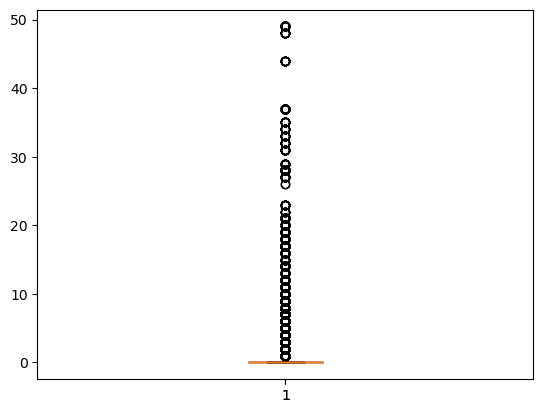

In [85]:
stat = statistike(S,A)
vertices = stat[1] #ljudi koji su povezani s bar 15 zajednica

S_, A_, vertices_in_S_ = get_neighbors_submatrix(S,A,vertices, depth=2) # generira neighbor matricu koja sadrži sve one čvorove koji imaju više od 15 zajednica, ali uzima njihove susjede do dubine 15 pa ćemo imati operabilnu dimenziju
print(S_.shape)

stat = statistike(S_,A_)
to_remove = stat[1] #ljudi koji su povezani s bar 15 zajednica, kojima cemo maknuti random zajednice

coef_lambda = 1
shape = (A_.shape[1], A_.shape[1])  
zero_matrix = csr_matrix(shape)
C = bmat([[coef_lambda * S_, A_], [A_.T, zero_matrix]], format='csr')

In [95]:
# krenimo s matricom C
num_recommendations =5
num_removed_groups =5
n = S_.shape[0]
k = A_.shape[1]

Ct , removed_groups = remove_random(C, n, to_remove, 0.5, num_removed_groups) # micanje zajednica
recommendation_matrix = Katz_matrix(Ct).toarray()


num_true_positive = true_positive(Ct,recommendation_matrix,removed_groups,n, index = to_remove, num_recommendations= num_recommendations)
TPR = num_true_positive/num_removed_groups/len(removed_groups)
FPR = (n*num_recommendations-num_true_positive)/(sum(C[:n, :][:, n:].data))

print(TPR)


MemoryError: Unable to allocate 1.54 GiB for an array with shape (14363, 14363) and data type float64

In [107]:
import matplotlib.pyplot as plt

# Generate x-values
x = np.linspace(5, 15, 11)  # Range of x from -2 to 2 with 500 points

gx=x
fgx=x

for k in range (5, 15):
    gx[k] = mean_true_positive(Ct,recommendation_matrix,removed_groups,n, index = to_remove, num_recommendations= k+1)          # g(x) = x^2
    fgx [k] = mean_specificity(Ct,recommendation_matrix,removed_groups,n, index = to_remove, num_recommendations= k+1)

# Plot f(g(x)) as a function of g(x)
plt.figure(figsize=(8, 6))
plt.plot(gx, fgx, label="$ROC curve$", linewidth=2)

# Add labels and title
plt.title("", fontsize=14)
plt.xlabel("FPR", fontsize=12)
plt.ylabel("TPR", fontsize=12)
plt.grid(True)
plt.legend()
plt.show()


548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1, 14363)
548550
(1,

IndexError: column index (548551) out of range

In [ ]:
# podaci za wiki
def load_communities_wiki(lokacija,n,k): # za amazon dataset
    rows = []
    cols = []
    data = []
    with open(lokacija, "r") as file:
        num = 0
        
        for line in file:
            row = [int(num) for num in line.strip().split(" ")[1:]]
            cols += ([num for i in range(len(row))])
            rows += row
            data += ([1 for i in range(len(row))])
            num += 1
    return sp.sparse.coo_matrix((data,(rows,cols)), shape = (n,k))

In [236]:
# amazon dataset

k = 17400# ovo sam izvukao iz podataka


prijateljstva = pd.read_csv("com-amazon.ungraph.txt", sep= '\t') # ucitavanje podatke
a = prijateljstva.iloc[:,0].to_numpy() 
b = prijateljstva.iloc[:,1].to_numpy() 
rows = np.concatenate((a,b))
cols = np.concatenate((b,a))

n = max(max(rows),max(cols))+1
data = np.ones((rows.shape[0]))
S = sp.sparse.coo_matrix((data,(rows,cols)), shape = (n,n), dtype=bool)


A = load_communities("com-amazon.top5000.cmty.txt",n,k)

coef_lambda = 1
zero_matrix = csr_matrix((k,k))
C = bmat([[coef_lambda * S, A], [A.T, zero_matrix]], format='csr')
I = sp.sparse.eye(C.shape[0], format='csr')

(26050, 26050)


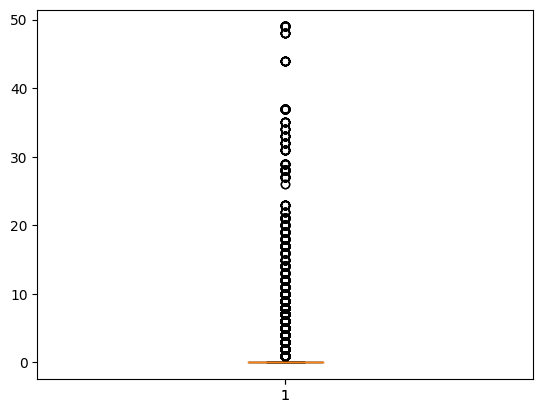

In [243]:
stat = statistike(S,A)
vertices = stat[1] #ljudi koji su povezani s bar 15 zajednica

S_, A_, vertices_in_S_ = get_neighbors_submatrix(S,A,vertices, depth=6) # generira neighbor matricu koja sadrži sve one čvorove koji imaju više od 15 zajednica, ali uzima njihove susjede do dubine 15 pa ćemo imati operabilnu dimenziju
print(S_.shape)

stat = statistike(S_,A_)
to_remove = stat[1] #ljudi koji su povezani s bar 15 zajednica, kojima cemo maknuti random zajednice

coef_lambda = 1
shape = (A_.shape[1], A_.shape[1])  
zero_matrix = csr_matrix(shape)
C = bmat([[coef_lambda * S_, A_], [A_.T, zero_matrix]], format='csr')

In [245]:
# krenimo s matricom C
num_recommendations =15
num_removed_groups =15
n = S_.shape[0]
k = A_.shape[1]

Ct , removed_groups = remove_random(C, n, to_remove, 0.5, num_removed_groups) # micanje zajednica
recommendation_matrix = Katz_matrix(Ct).toarray()


num_true_positive = true_positive(Ct,recommendation_matrix,removed_groups,n, index = to_remove, num_recommendations= num_recommendations)
TPR = num_true_positive/num_removed_groups/len(removed_groups)
FPR = (n*num_recommendations-num_true_positive)/(sum(C[:n, :][:, n:].data))

print(TPR)


0.7418803418803418
